# Regressão:

Problemas de regressão tratam-se de situção em que se deseja estimar o valor de uma varíavel continua a partir de um conjunto de métricas. 



**Agloritmos do experimento:**

* Decision Tree
* Random Forest
* Linear Regression
* Knn Regression
* Lr lasso
* Lr ridge
* Lr Elastic Net
* Polinomial Regression
* XGBoost

In [54]:
from sklearn.tree           import DecisionTreeRegressor      as dtr 
from sklearn.ensemble       import RandomForestRegressor      as rfr 
from sklearn.linear_model   import LinearRegression           as lr 
from sklearn.linear_model   import Ridge                      as rg 
from sklearn.linear_model   import Lasso                      as ls
from sklearn.linear_model   import ElasticNet                 as en 
from sklearn.neighbors      import KNeighborsRegressor        as knr
from sklearn.metrics        import mean_absolute_error        as mae
from sklearn.metrics        import root_mean_squared_error    as rmse
from sklearn.metrics        import r2_score                   as r2
from sklearn.metrics        import mean_absolute_percentage_error as mape
from sklearn.preprocessing  import PolynomialFeatures            as pf
from matplotlib import pyplot as plt 
import pandas as pd
import sys 
import numpy as np 
from tqdm import tqdm 
sys.path.append('../../libs/src')
from data_utils import normalizer  

#from sklearn.ensemble     import GradientBoostingRegressor as gbr

# Dataset: 


In [19]:
X_dataset = {}
X_dataset['training'] = pd.read_csv('../data/X_training.csv')
X_dataset['test'] = pd.read_csv('../data/X_test.csv') 
X_dataset['validation'] = pd.read_csv('../data/X_validation.csv')

y_dataset = {}
y_dataset['training'] = pd.read_csv('../data/y_training.csv')
y_dataset['test'] = pd.read_csv('../data/y_test.csv') 
y_dataset['validation'] = pd.read_csv('../data/y_validation.csv')

y_log_dataset = {}
y_log_dataset['training'] = y_dataset['training'].apply(lambda x: np.log1p(x))
y_log_dataset['test'] = y_dataset['test'].apply(lambda x: np.log1p(x))
y_log_dataset['validation'] = y_dataset['validation'].apply(lambda x: np.log1p(x)) 

In [20]:
X_normalized_dataset = {}
y_normalized_dataset = {}
normalizador = normalizer(X_dataset['training'],
                          strategy = 'minMaxScaller')
for k in X_dataset.keys():
    X_normalized_dataset[k] = normalizador.getDfcolumnNormalized(X_dataset[k])



#### Normalizacao de y depende de avaliação da sua distribuição

In [21]:
y_dataset['training'].describe()

,song_popularity
count,10547.000000
mean,53.046961
std,21.864535
min,0.100000
25%,40.000000
50%,56.000000
75%,69.000000
max,100.000000


{'whiskers': [<matplotlib.lines.Line2D at 0x7b1d200a1a20>,
 'caps': [<matplotlib.lines.Line2D at 0x7b1d200a2170>,
 'boxes': [<matplotlib.lines.Line2D at 0x7b1d200a1ba0>],
 'medians': [<matplotlib.lines.Line2D at 0x7b1d200a2b90>],
 'fliers': [<matplotlib.lines.Line2D at 0x7b1d200a2470>],
 'means': []}

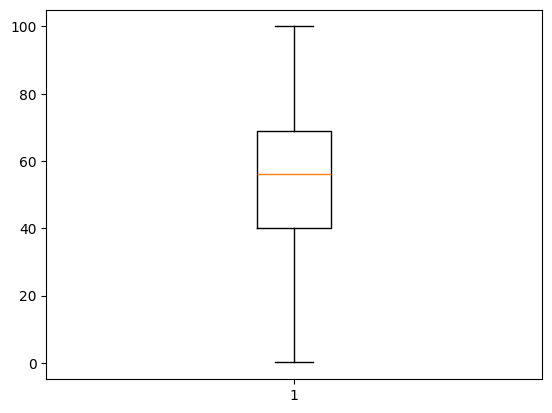

In [22]:
plt.boxplot(y_dataset['training'])

array([[<Axes: title={'center': 'song_popularity'}>]], dtype=object)

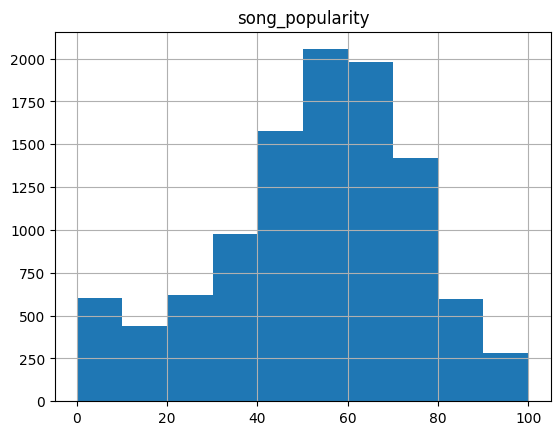

In [5]:
y_dataset['training'].hist()

# Utils

In [6]:
from typing import Literal
import matplotlib.pyplot as plt


class regressor():
    
    def __init__(self,
                 x_dataset,
                 y_dataset,
                 modelName   : str, 
                 modelParams : dict = 'default',
                 verbose     : bool = False):
        
        self.x_dataset   = x_dataset
        self.y_dataset   = y_dataset
        self.modelParams = modelParams
        self.modelName   = modelName
        self.verbose     = verbose
        
    def getBestModel(
                    self,
                    metricEvaluated : Literal['mae','rmse','r2','mape']='mae') -> dict: 
        
        '''
        args: results : dict like {
            ['mae'       : {'training':..., 'test':..., 'validation':...},
            ..., 
            'modelName' : modelName
            ]}
        '''
        eval_metrics = []
        
        for item in self.model_results:
            eval_metrics.append(item[metricEvaluated]['validation']) 

        best_index = eval_metrics.index(min(eval_metrics))

        return self.model_results[best_index] 
        

    def getModelPredictions(self,
                            model):

        y_predicted = {}
        y_predicted['training']     = model.predict(self.x_dataset['training'])
        y_predicted['test']         = model.predict(self.x_dataset['test'])
        y_predicted['validation']   = model.predict(self.x_dataset['validation'])
        
        return y_predicted
    

    def getSortedDataset(self,y_predicted, y_true):
        
        df = pd.DataFrame(y_predicted, columns=['predicted'])
        df['true'] = y_true.reset_index(drop=True)
        df = df.sort_values(by='true').reset_index(drop=True)
        
        return df


    def drawPlots(self, 
                y_predicted):
        
        # generate a subplots for training, test and validation datasets, each once needs to be a line  
        
        fig, ax = plt.subplots(3, 1, figsize=(18,9))
        
        sorted_training = self.getSortedDataset(y_predicted['training'],   self.y_dataset['training'])
        sorted_valid    = self.getSortedDataset(y_predicted['validation'], self.y_dataset['validation'])
        sorted_test     = self.getSortedDataset(y_predicted['test'],       self.y_dataset['test'])


        ax[0].scatter(y = sorted_training['true'].values, x = [x for x in range(0,len(sorted_training))], label='True values', color='blue')
        ax[0].plot(sorted_training['predicted'], label='Predicted values', color = 'red')
        ax[0].set_title('Training dataset')
        ax[0].legend()

        ax[1].scatter(y = sorted_test['true'].values, x = [x for x in range(0,len(sorted_test))], label='True values', color='blue')
        ax[1].plot(sorted_test['predicted'], label='Predicted values', color = 'red')
        ax[1].set_title('Training dataset')
        ax[1].legend()


        ax[2].scatter(y = sorted_valid['true'].values, x = [x for x in range(0,len(sorted_valid))], label='True values', color='blue')
        ax[2].plot(sorted_valid['predicted'], label='Predicted values', color = 'red')
        ax[2].set_title('Validation dataset')
        ax[2].legend()
        

    def compute_metrics(self, 
                        y_predicted : dict):
    
        '''
        
        Compute regression metrics: MAE, RMSE, R2, MAPE for training, test and validation datasets.
        args:
            y_dataset       : dict with true values for 'training', 'test' and 'validation' datasets
            y_predicted    : dict with predicted values for 'training', 'test'
        
        '''
        
        mae_results = {
            'training'  : mae(self.y_dataset['training'],  y_predicted['training']),
            'test'      : mae(self.y_dataset['test'],      y_predicted['test']),
            'validation': mae(self.y_dataset['validation'],     y_predicted['validation'])
        }
        rmse_results = {
            'training'  : rmse(self.y_dataset['training'],  y_predicted['training']),
            'test'      : rmse(self.y_dataset['test'],      y_predicted['test']),
            'validation': rmse(self.y_dataset['validation'],     y_predicted['validation'])
        }

        r2_results = {
            'training'  : r2(self.y_dataset['training'],  y_predicted['training']),
            'test'      : r2(self.y_dataset['test'],      y_predicted['test']),
            'validation': r2(self.y_dataset['validation'],     y_predicted['validation'])
        }

        mape_results = {
            'training'  : mape(self.y_dataset['training'],  y_predicted['training']),
            'test'      : mape(self.y_dataset['test'],      y_predicted['test']),
            'validation': mape(self.y_dataset['validation'],     y_predicted['validation'])
        }


        if self.verbose:
            print('--- Training ---')
            print('MAE  :', mae_results['training'])
            print('RMSE :', rmse_results['training'])
            print('R2   :', r2_results['training'])
            print('MAPE :', mape_results['training'])   

            print('--- Test ---')

            print('MAE  :', mae_results['test'])
            print('RMSE :', rmse_results['test'])
            print('R2   :', r2_results['test'])
            print('MAPE :', mape_results['test'])

            print('--- Validation ---')
            print('MAE  :', mae_results['validation'])
            print('RMSE :', rmse_results['validation'])
            print('R2   :', r2_results['validation'])
            print('MAPE :', mape_results['validation']) 


        results = {
            'mae'       : mae_results,
            'rmse'      : rmse_results,
            'r2'        : r2_results,
            'mape'      : mape_results,
            'modelName' : self.modelName,
            'modelParams' : str(self.modelParams)
        }

        return results
    
    def fitAndEvaluate(self,
                       model):

        model.fit(self.x_dataset['training'], self.y_dataset['training'])
        predictions         = self.getModelPredictions(model)      
        self.model_results  = self.compute_metrics(predictions)

        self.model_results['model'] = self.modelName

        self.drawPlots(predictions)
        
        return model


# Treinando os modelos

## 2.1 - Modelos Lineares

### 2.1.1 - Regressão linear

{'mae': {'training': 16.998249066011095, 'test': 17.12996509166612, 'validation': 17.039753759960327}, 'rmse': {'training': 21.35406546364478, 'test': 21.480868682071254, 'validation': 21.41137645841414}, 'r2': {'training': 0.04605830473391903, 'test': 0.052317119521687494, 'validation': 0.03992483038154071}, 'mape': {'training': 8.653185943804512, 'test': 8.521859277849835, 'validation': 8.682541883735295}, 'modelName': 'Linear Regression', 'modelParams': 'default', 'model': 'Linear Regression'}


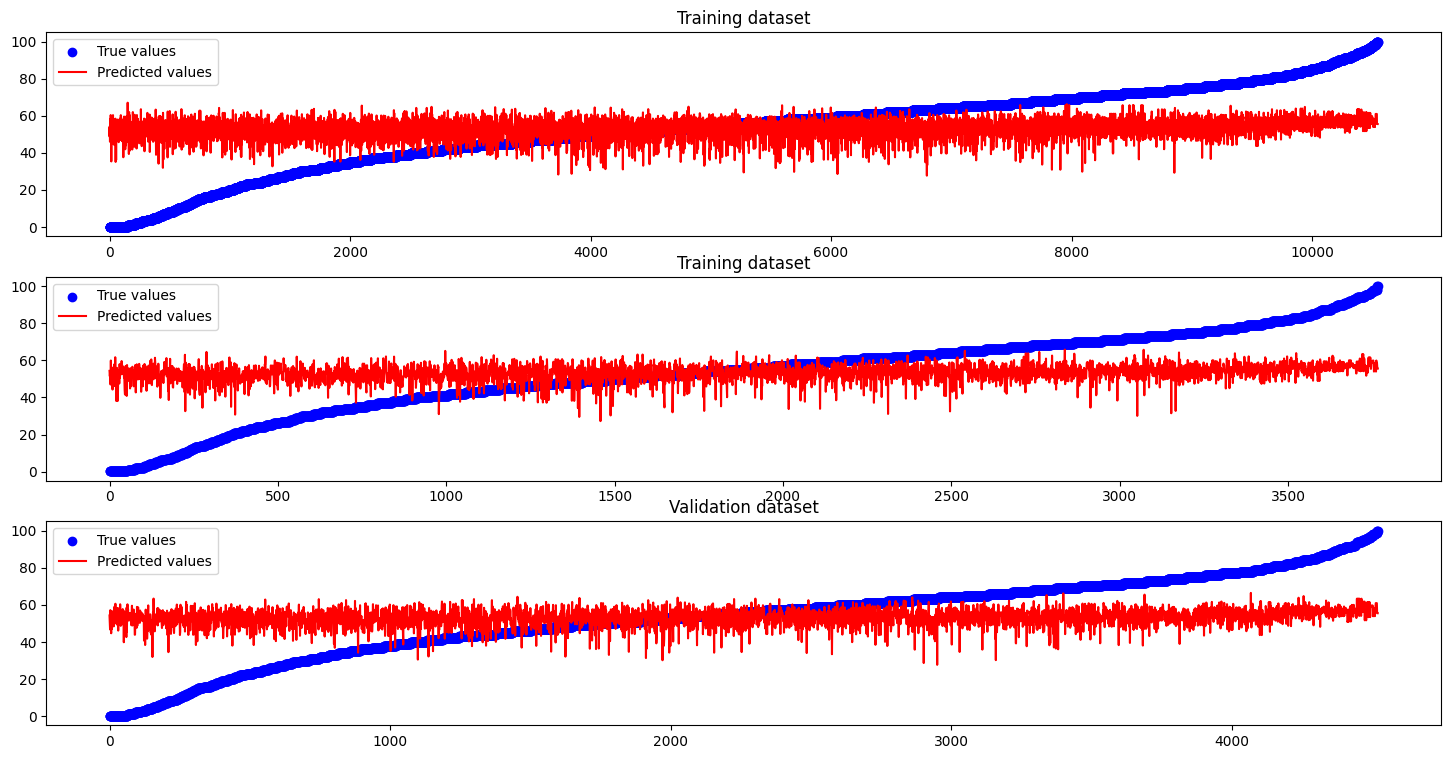

In [7]:
class linearRegressionModel(regressor):

    
    def __init__(self,
                 x_dataset : dict, 
                 y_dataset : dict, 
                 mondelName : str   = 'Linear Regression',
                 modelParams : dict = 'default'):
        
        super().__init__(x_dataset      = x_dataset, 
                         y_dataset      = y_dataset, 
                         modelName      = mondelName,
                         modelParams    = modelParams,
                         verbose=False
                         )
        

linearRegression = linearRegressionModel(X_normalized_dataset, y_dataset) 
linearRegression.fitAndEvaluate(lr())
print(linearRegression.model_results)

### 2.1.2 Regressão linear l1 - lasso 

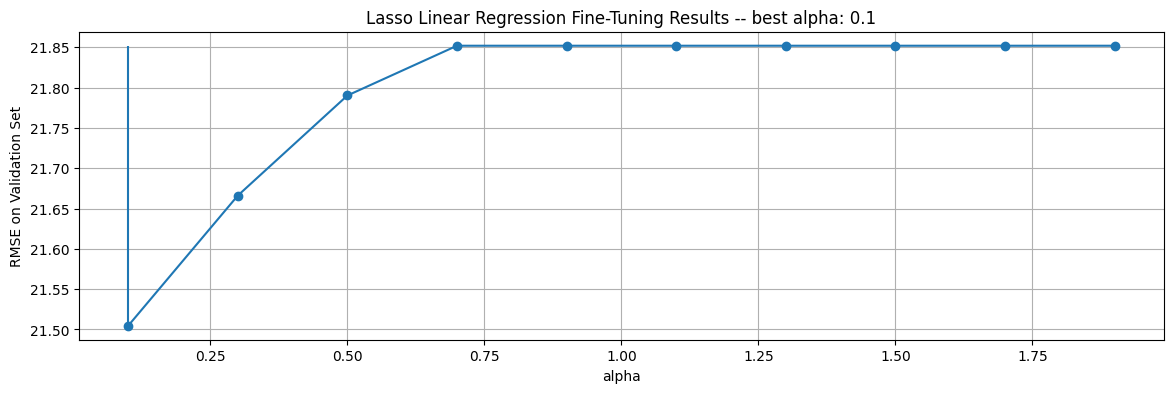

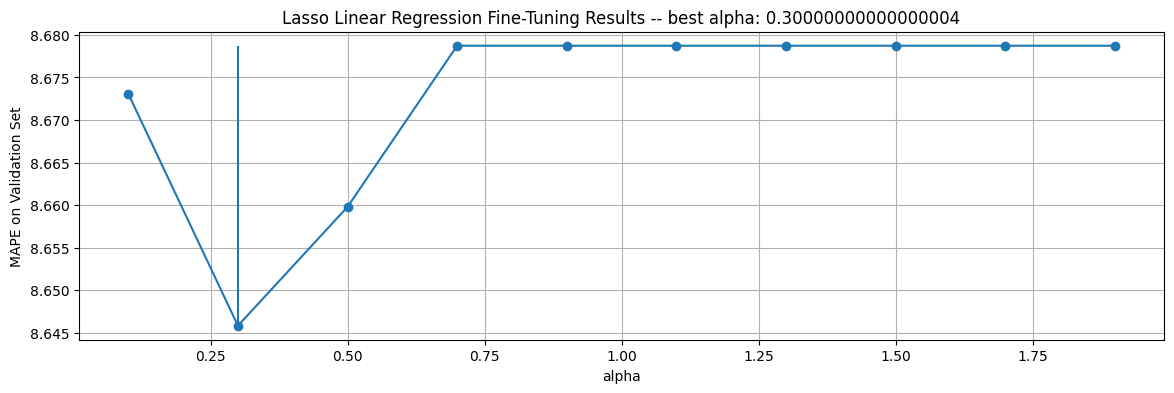

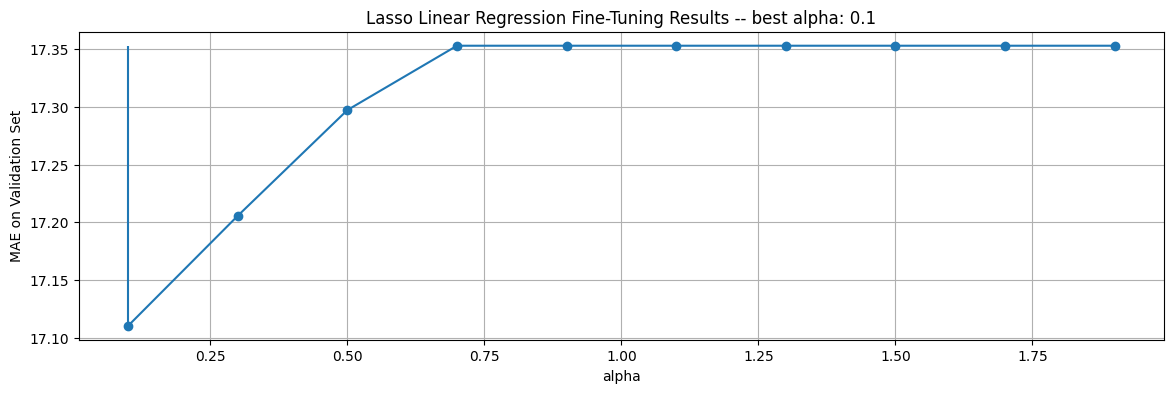

In [23]:
class linearRegressionRegularized(regressor):

    
    def __init__(self,
                 x_dataset : dict, 
                 y_dataset : dict, 
                 regularization : Literal['ridge','lasso'] = 'lasso',
                 modelName : str   = 'Lasso Linear Regression',
                 modelParams : dict = 'default',
                 verbose : bool = False):
        

        super().__init__(x_dataset      = x_dataset, 
                         y_dataset      = y_dataset, 
                         modelName      = modelName,
                         modelParams    = modelParams,
                         verbose       = verbose
                         )
        
        self.model_results = []
        self.regularization = regularization
        self.alpha_values = self.modelParams.get('alpha')
        self.l1_ratio_values = self.modelParams.get('l1_ratio', [0.5])

        self.models = {
            'lasso'      : ls,
            'ridge'      : rg,
            'elasticNet' : en
        }
        
    def fineTunning(self,
                    metricEvaluated : Literal['mae','rmse','r2','mape']='mae'):

        for alpha in self.alpha_values:
            for l1_ratio in self.l1_ratio_values:
                linearRegressor = self.models[self.regularization](alpha = alpha) if self.regularization in ['ridge','lasso'] else self.models[self.regularization](alpha = alpha, l1_ratio=l1_ratio)
                linearRegressor.fit(self.x_dataset['training'], 
                                    self.y_dataset['training'])

                lr_predictions  = self.getModelPredictions(linearRegressor)      

                model_results              = self.compute_metrics(lr_predictions)
                
                model_results['alpha'] = alpha
                model_results['l1_ratio'] = l1_ratio
                
                model_results['model']     = self.modelName

                self.model_results.append(model_results)
        
            self.best_model = self.getBestModel(metricEvaluated=metricEvaluated)
    
        

    def _set_results_df(self):
        self.results_df = pd.DataFrame(self.model_results)
        #self.results_df.reset_index(drop=False, inplace=True)
        #self.results_df.rename(columns = {'index':'dataset'}, inplace=True)


    def drawFineTunningResults(self,
                               metricEvaluated : Literal['mae','rmse','r2','mape']='mae',
                               parameterEvaluated : Literal['alpha','l1_ratio']='alpha'):


        self._set_results_df()


        best_parameter = self.getBestModel(metricEvaluated=metricEvaluated)[parameterEvaluated]
        
        # Como estou avaliando somente 1 parametro na analise, fixo o outro parametro com o valor correspondente ao do melhor modelo 
        fixed_parameter = 'l1_ratio' if parameterEvaluated == 'alpha' else 'alpha' # o parametro fixado sera o outro parametro que nao esta sendo avaliado
        
        fixed_parameter_value   = self.best_model[fixed_parameter]
        
        # avaliarremos somente os experimentos que possuem o valor do parametro fixado igual ao do melhor modelo
        experiments_to_evaluate = self.results_df[self.results_df[fixed_parameter] == fixed_parameter_value]
        
        parameters = experiments_to_evaluate[parameterEvaluated].tolist()
        list_dict_loss   = experiments_to_evaluate[metricEvaluated].values
        loss = [item['validation'] for item in list_dict_loss]
        
        plt.figure(figsize=(14,4))
        
        plt.plot(parameters, loss, marker='o')
       # plt.xscale('log')
        plt.xlabel('alpha')
        plt.ylabel(f'{metricEvaluated.upper()} on Validation Set')
        plt.title(f'{self.modelName} Fine-Tuning Results -- best alpha: {best_parameter}')

        plt.vlines(x = best_parameter,
                   ymin = min(loss),
                   ymax = max(loss))       
         
        plt.grid(True)
        plt.show()
        


parameters = {
    'alpha' : [x for x in np.arange(0.1, 2.1, 0.2)]
}

lasso = linearRegressionRegularized(x_dataset=X_normalized_dataset, 
                                   y_dataset=y_dataset, 
                                   modelParams=parameters,
                                   regularization='lasso')
 
lasso.fineTunning()

lasso.drawFineTunningResults(metricEvaluated='rmse')
lasso.drawFineTunningResults(metricEvaluated='mape')
lasso.drawFineTunningResults(metricEvaluated='mae')





**Observação importante:**

O parametro aplha que minimiza o rmse e o mae, não é o mesmo que minimiza o mape. 

Isso ocorre pois o rmse e o mape ponderam de maneira diferente os erros. Enquanto para o rmse e mse o que vale é o valor absoluto, para o mape o que vale é a o erro relativo ser homogeneo. 

Isso levanta a questão de que cada métrica é mais adequada para determinados cenários. Se meu objetivo fosse estimar a venda de um conjunto de lojas individualmente, é possível que um mape menor fosse mais interessante, pois colocaria todos na mesma "regua". Porém se meu foco fosse estimar o faturamento total dae uma companhia baseado na venda de cada loja, pode ser que um rmse fosse mais adequado, pois elevaria o erro total ( e portanto final) a ser menor. 

Lasso(alpha=0.1)

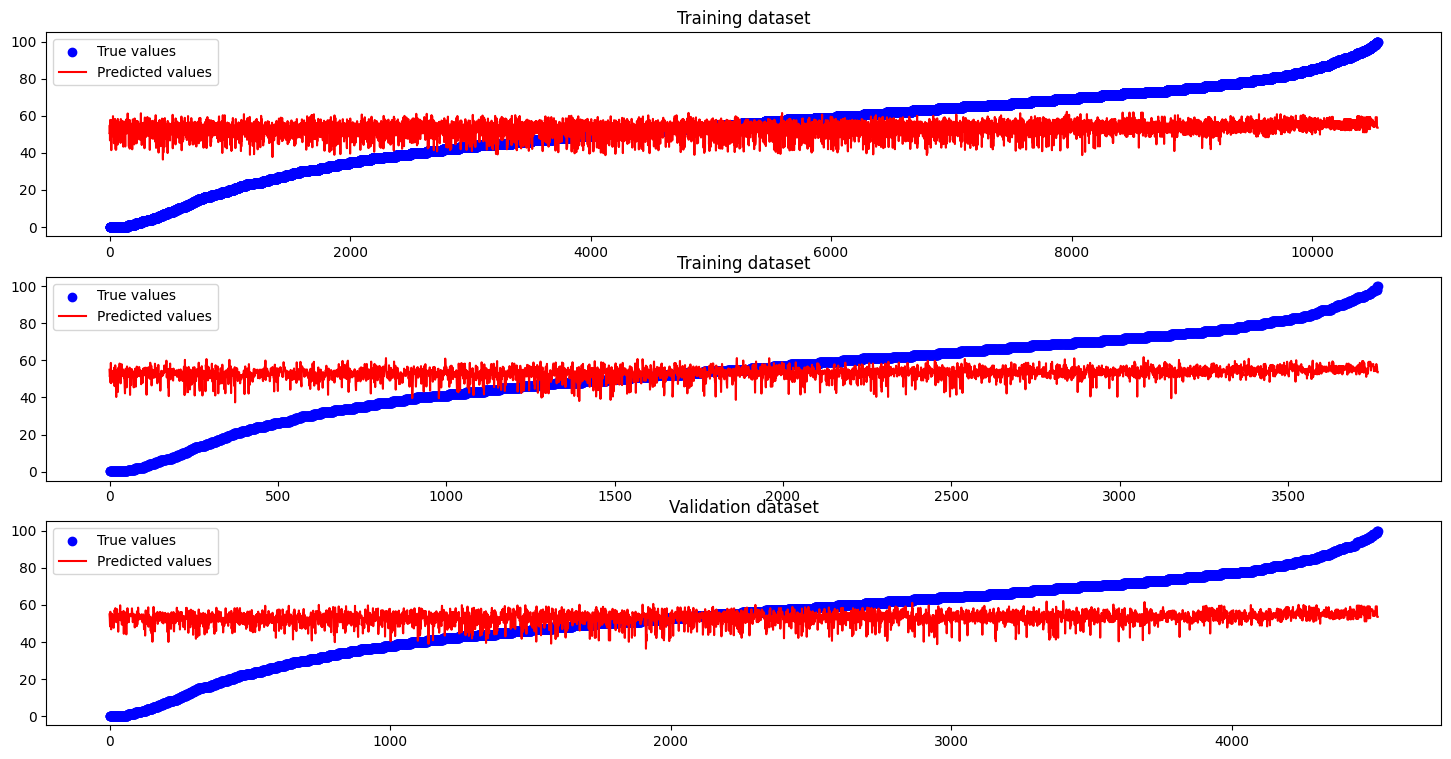

In [24]:
bestLasso = ls(alpha = lasso.best_model['alpha'])
lasso.fitAndEvaluate(bestLasso)

### 2.1.3 - Regressão Linear l2 - ridge

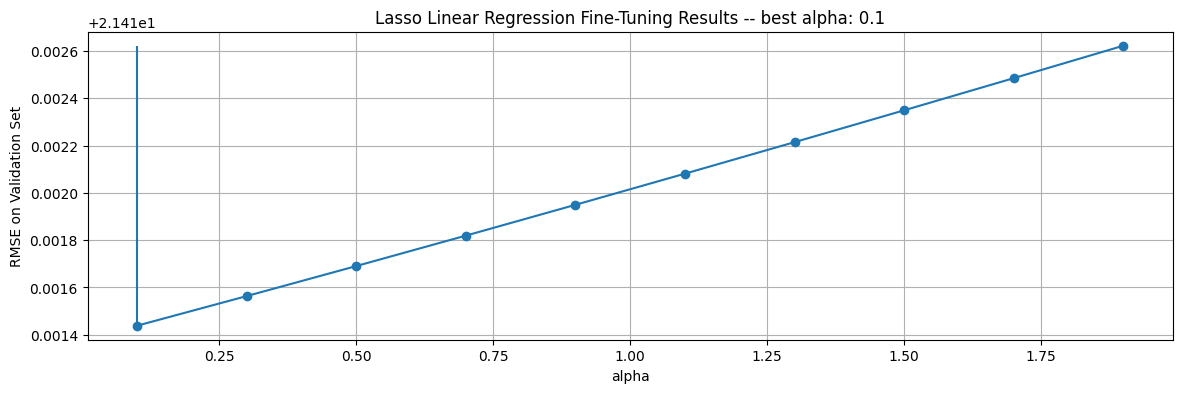

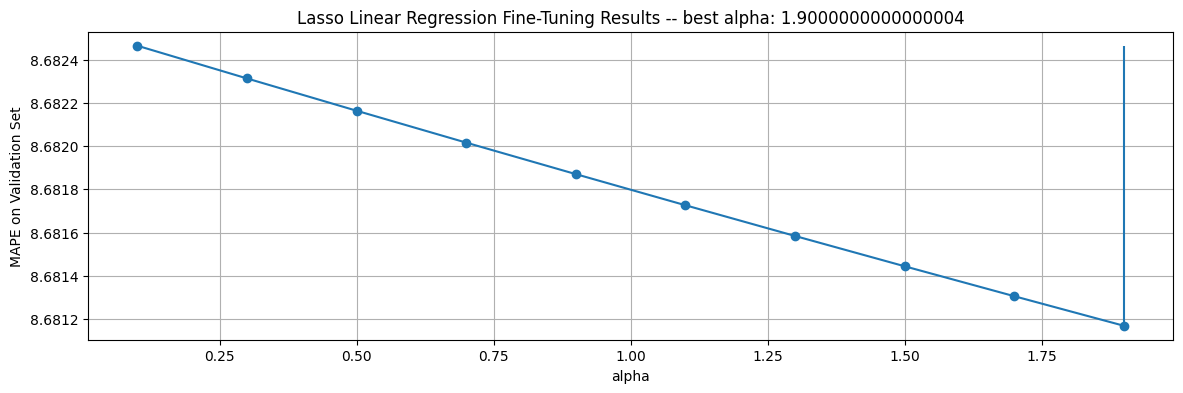

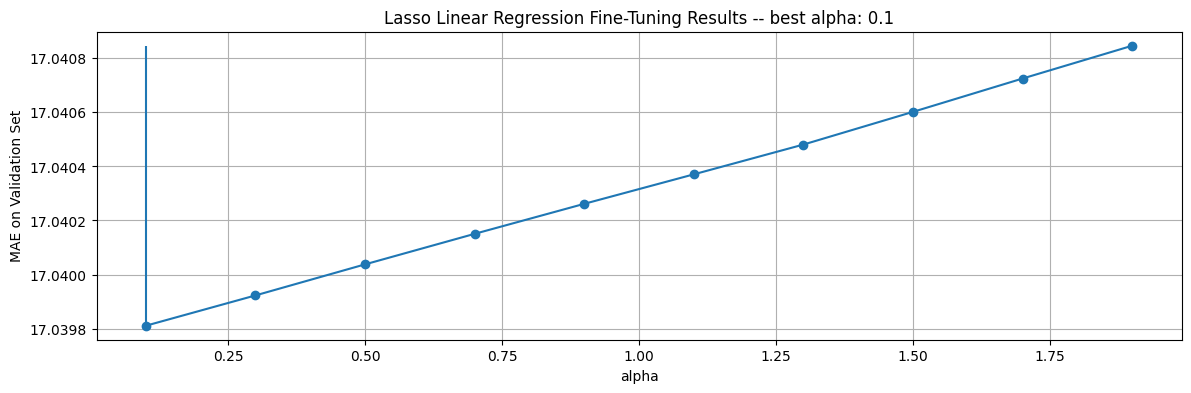

In [ ]:

parameters = {
    'alpha' : [x for x in np.arange(0.1, 2.1, 0.2)]
}

ridge = linearRegressionRegularized(x_dataset=X_normalized_dataset, 
                                   y_dataset=y_dataset, 
                                   modelParams=parameters,
                                   regularization='ridge')
 
ridge.fineTunning()

ridge.drawFineTunningResults(metricEvaluated='rmse')
ridge.drawFineTunningResults(metricEvaluated='mape')
ridge.drawFineTunningResults(metricEvaluated='mae')


### 2.1.4 - Regressão Linear l1 + l2 - elasticNet

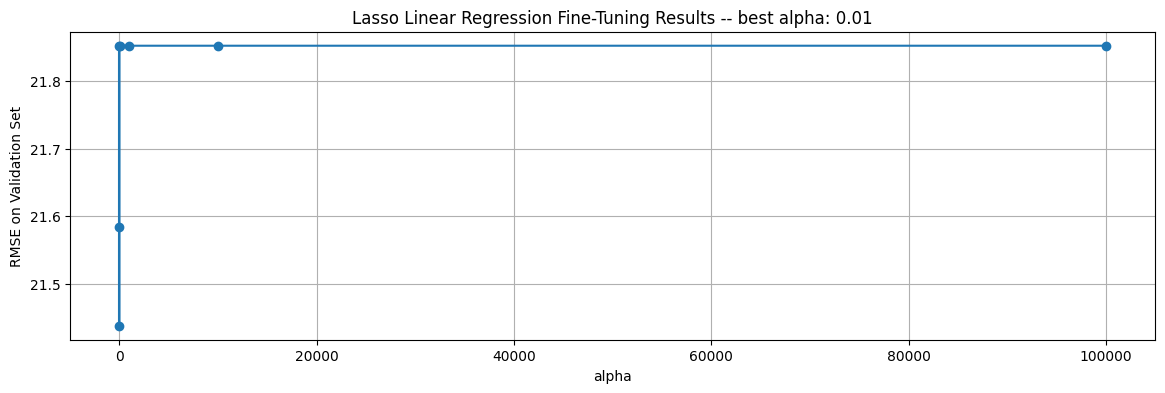

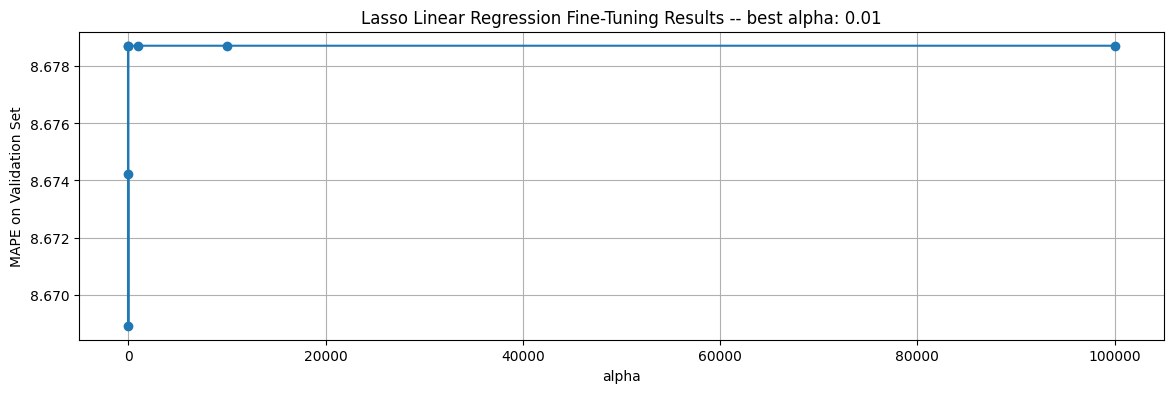

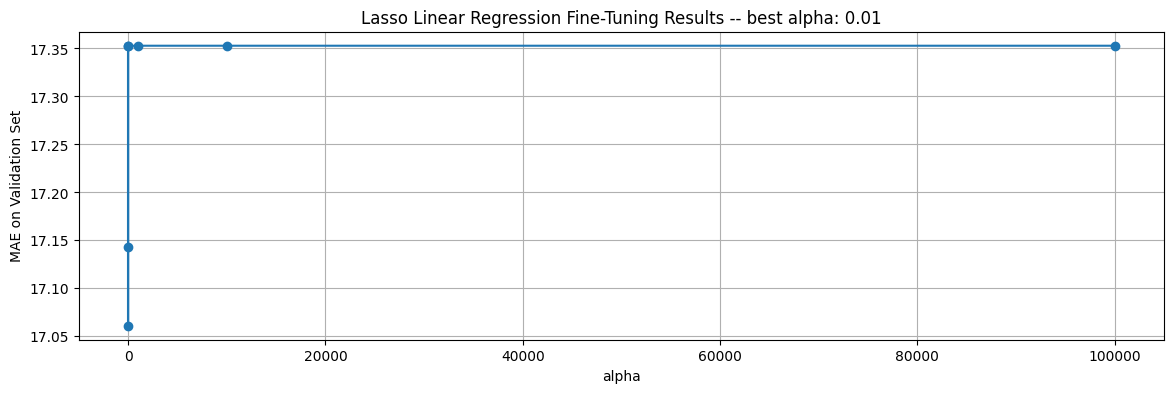

In [11]:

parameters = {
    'alpha' : [0.01, 0.1, 1.0, 10.0,10e2, 10e3, 10e4],
    'l1_ratio' : [0.3, 0.5, 0.7]
}

elastic_net = linearRegressionRegularized(x_dataset=X_normalized_dataset, 
                                   y_dataset=y_dataset, 
                                   modelParams=parameters,
                                   regularization='elasticNet')
 
elastic_net.fineTunning()

elastic_net.drawFineTunningResults(metricEvaluated='rmse')
elastic_net.drawFineTunningResults(metricEvaluated='mape')
elastic_net.drawFineTunningResults(metricEvaluated='mae')


ElasticNet(alpha=0.01)

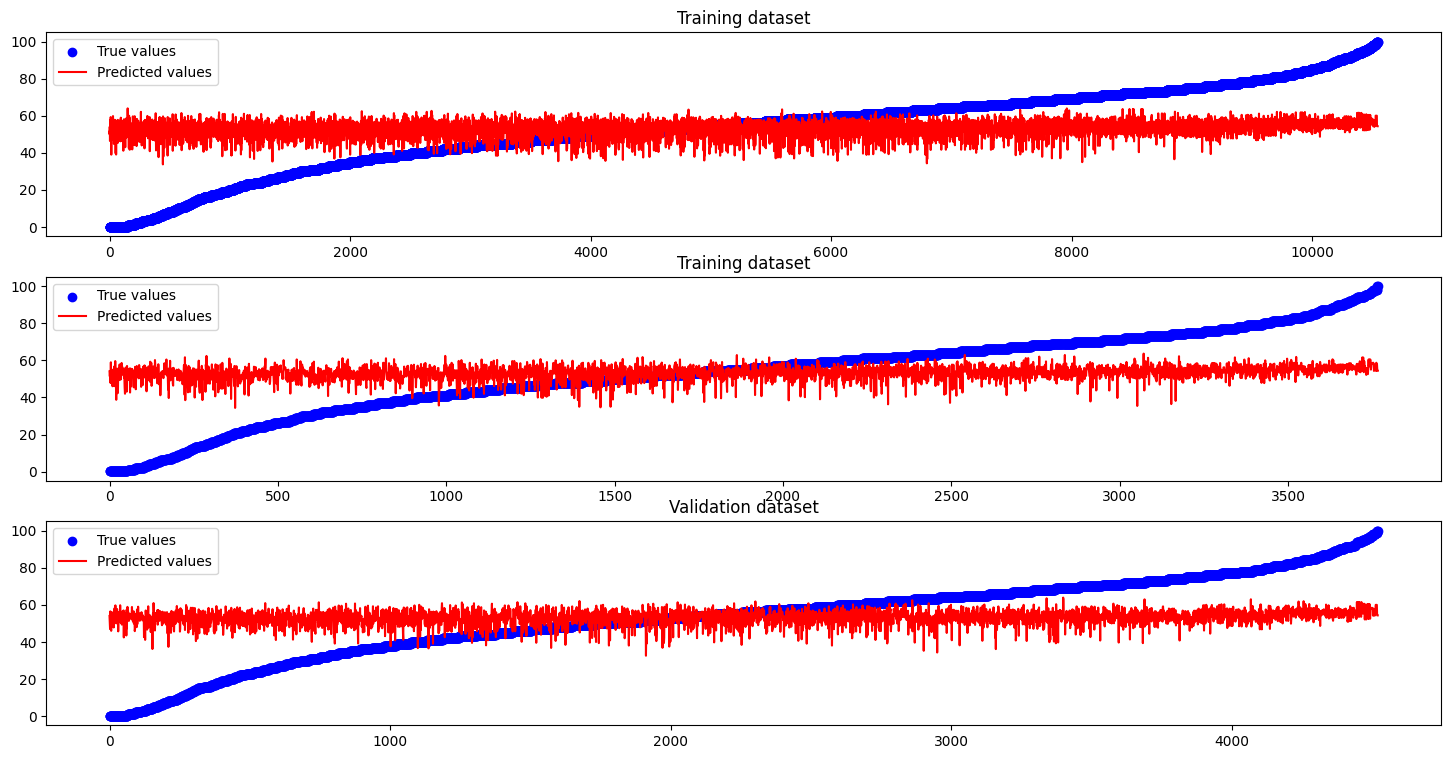

In [14]:
best_elastic_net = en(alpha = elastic_net.best_model['alpha'])
elastic_net.fitAndEvaluate(best_elastic_net)

## 2.2 Modelos mais complexos (lineares ou não)

### 2.2.1 - Decision Tree

In [52]:
class treeRegressorModels(regressor):

    
    def __init__(self,
                 x_dataset : dict, 
                 y_dataset : dict, 
                 modelName : str   = 'Decision Tree',
                 modelParamsFineTuning : dict = {'max_depth' : [5,10,15,20,25,30,35,40,45,50]},
                 treeRegressor : Literal['randomForest','decisionTree'] = 'decisionTree'):
                           
        '''
        modelParamsFineTuning {
            max_depth,
            n_estimators
        }
        
        '''                   
        super().__init__(x_dataset      = x_dataset, 
                         y_dataset      = y_dataset, 
                         modelName      = modelName,
                         modelParams    = modelParamsFineTuning,
                         verbose=False
                         )
        
        self.expectedFineTuningParams = ['max_depth', 'n_estimators']
        self.modelParamsFineTuning = modelParamsFineTuning
        self._checkFineTuningParams()
        self.model_results = []
        self.treeRegressor  = treeRegressor
        self.listMaxtDepth  = self.modelParamsFineTuning.get('max_depth')
        self.listEstimators = self.modelParamsFineTuning.get('n_estimators', [0])
        self.model = rfr if self.treeRegressor == 'randomForest' else dtr 

    def _checkFineTuningParams(self):
        for key in self.modelParamsFineTuning:
            if key not in self.expectedFineTuningParams:
                raise KeyError(f"O parametro {key} nao é valido como parametro para o fine tuning do modelo")
            

    def fitAndEvaluate(self, modelKwargs):
        return super().fitAndEvaluate(self.model(**modelKwargs))    
    
    
    def fineTunning(self,
                    metricEvaluated : Literal['mae','rmse','r2','mape']='mae'):

        for max_depth in tqdm(self.listMaxtDepth):
            for n_estimators in self.listEstimators:
                
                fitModel = self.model(max_depth = max_depth, n_estimators=n_estimators) if self.treeRegressor == 'randomForest' else self.model(max_depth=max_depth)
                fitModel.fit(self.x_dataset['training'], 
                                    self.y_dataset['training'])

                predictions  = self.getModelPredictions(fitModel)      

                model_results              = self.compute_metrics(predictions)
                
                model_results['max_depth']      = max_depth
                model_results['n_estimators']   = n_estimators
                
                model_results['model']     = self.modelName

                self.model_results.append(model_results)
        
            self.best_model = self.getBestModel(metricEvaluated=metricEvaluated)
    
        

    def _set_results_df(self):
        self.results_df = pd.DataFrame(self.model_results)
        #self.results_df.reset_index(drop=False, inplace=True)
        #self.results_df.rename(columns = {'index':'dataset'}, inplace=True)


    def drawFineTunningResults(self,
                               metricEvaluated : Literal['mae','rmse','r2','mape']='mae',
                               parameterEvaluated : Literal['max_depth','n_estimators']='max_depth'):


        self._set_results_df()


        best_parameter = self.getBestModel(metricEvaluated=metricEvaluated)[parameterEvaluated]
        
        # Como estou avaliando somente 1 parametro na analise, fixo o outro parametro com o valor correspondente ao do melhor modelo 
        fixed_parameter = 'n_estimators' if parameterEvaluated == 'max_depth' else 'max_depth' # o parametro fixado sera o outro parametro que nao esta sendo avaliado
        
        fixed_parameter_value   = self.best_model[fixed_parameter]
        
        # avaliarremos somente os experimentos que possuem o valor do parametro fixado igual ao do melhor modelo
        experiments_to_evaluate = self.results_df[self.results_df[fixed_parameter] == fixed_parameter_value]
        
        parameters = experiments_to_evaluate[parameterEvaluated].tolist()
        list_dict_loss   = experiments_to_evaluate[metricEvaluated].values
        lossValidation = [loss['validation'] for loss in list_dict_loss]
        lossTraining   = [loss['training']   for loss in list_dict_loss]

        plt.figure(figsize=(14,4))
        
        plt.plot(parameters, lossValidation, marker='o', label = 'validation', color = 'blue')
       # plt.xscale('log')
        plt.xlabel(metricEvaluated.upper())
        plt.ylabel(f'{metricEvaluated.upper()} on Validation Set')
        plt.title(f'{self.modelName} Fine-Tuning Results -- best {metricEvaluated.upper()}: {best_parameter}')

        plt.plot(parameters, lossTraining, marker='o', label = 'training', color = 'red')
        plt.xlabel(metricEvaluated.upper())
        plt.ylabel(f'{metricEvaluated.upper()} on Training Set')
        plt.title(f'{self.modelName} Fine-Tuning Results -- best {metricEvaluated.upper()}: {best_parameter}')
        plt.legend()



        plt.vlines(x = best_parameter,
                   ymin = min(lossTraining),
                   ymax = max(lossValidation))       
         
        plt.grid(True)
        plt.show()
        

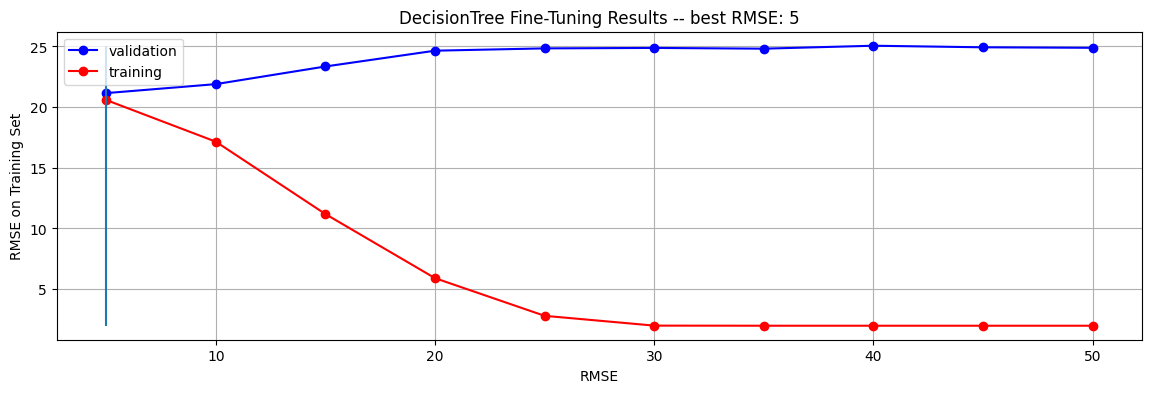

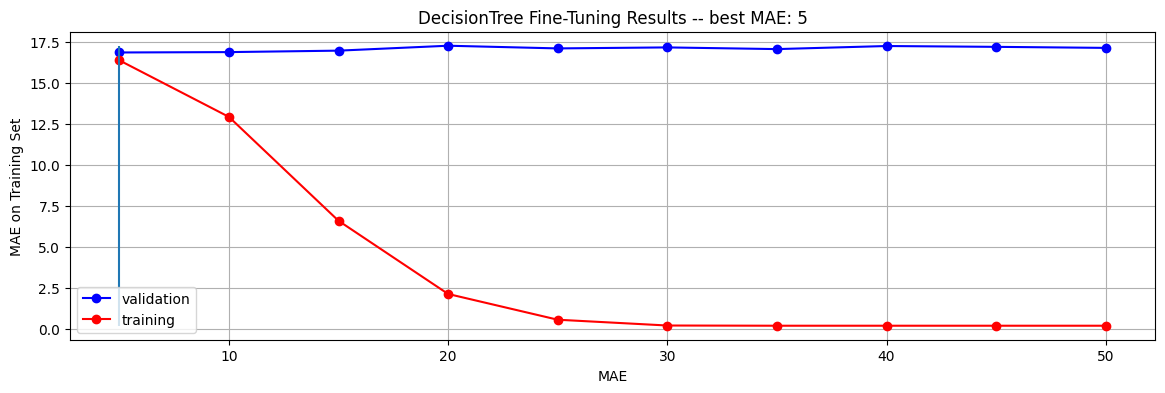

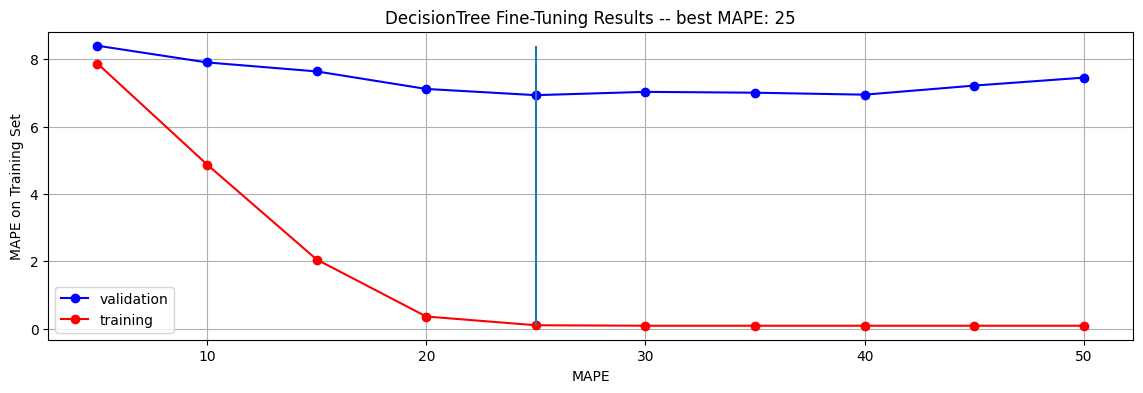

In [44]:
dtrParams = {
    'max_depth' : [5,10,15,20,25,30,35,40,45,50]
}
decisionTreeRegressor = treeRegressorModels(X_normalized_dataset, y_dataset,
                                            modelName='DecisionTree',
                                            treeRegressor='decisionTree',
                                            modelParamsFineTuning=dtrParams)
 

decisionTreeRegressor.fineTunning(metricEvaluated='rmse')

decisionTreeRegressor.drawFineTunningResults(metricEvaluated='rmse')
decisionTreeRegressor.drawFineTunningResults(metricEvaluated='mae')
decisionTreeRegressor.drawFineTunningResults(metricEvaluated='mape')


DecisionTreeRegressor(max_depth=5, max_features='log2')

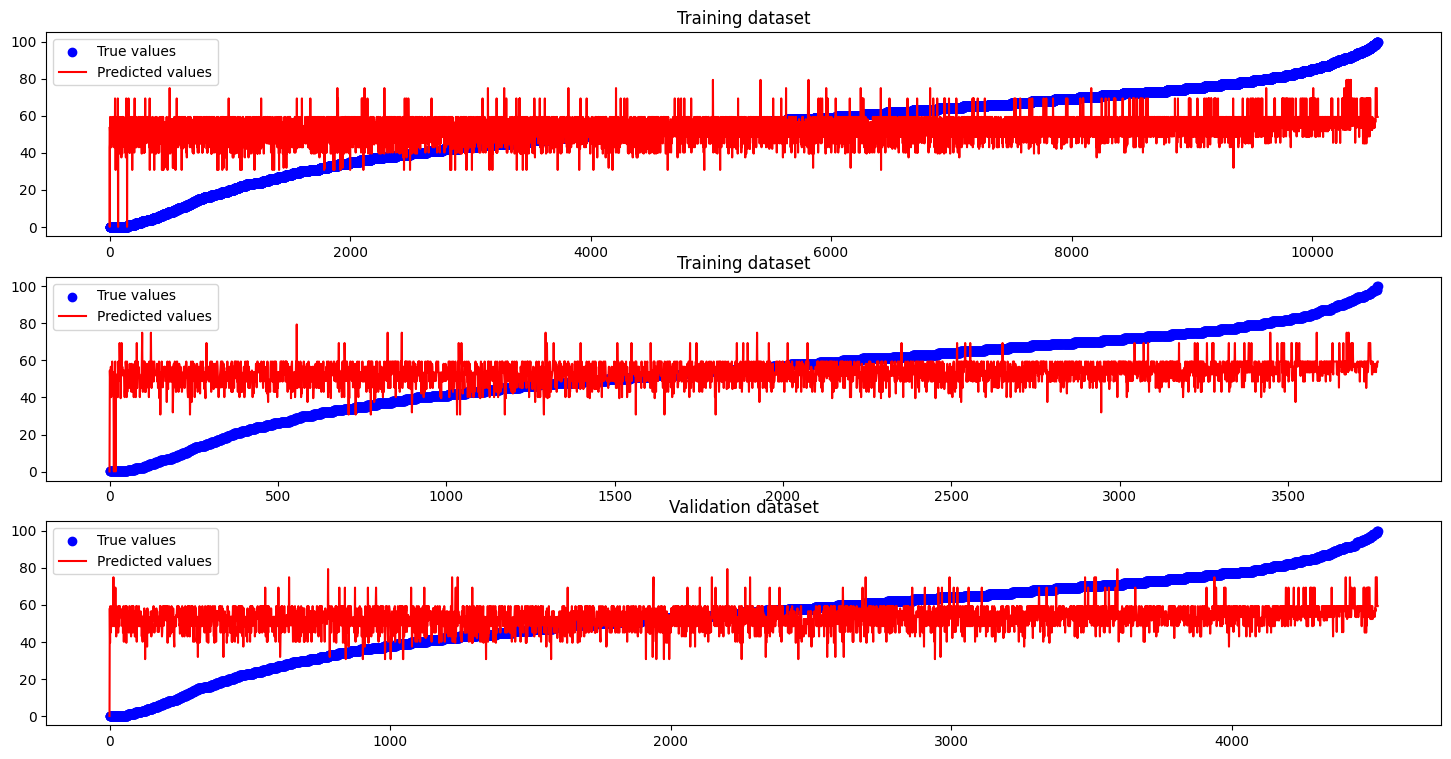

In [45]:
dtrKwargs = {
    'max_depth' : 5,
    'max_features' : 'log2'   
}
decisionTreeRegressor.fitAndEvaluate(dtrKwargs)

### 2.2.2 - RandomForest

In [55]:
rfParams = {
    'max_depth' : [5,20,30,40,50],
    'n_estimators' : [30,50,70,90,110]
}


randomForestRegressor = treeRegressorModels(X_normalized_dataset, y_dataset,
                                            modelName='randomForest',
                                            treeRegressor='randomForest',
                                            modelParamsFineTuning=rfParams)
 

randomForestRegressor.fineTunning(metricEvaluated='rmse')


  0%|          | 0/5 [00:00<?, ?it/s]/home/p123/.local/lib/python3.10/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/p123/.local/lib/python3.10/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/p123/.local/lib/python3.10/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/p123/.local/lib/python3.10/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expect

In [51]:
randomForestRegressor.results_df[randomForestRegressor.results_df.max_depth == 50]

,mae,rmse,r2,mape,modelName,modelParams,max_depth,n_estimators,model
20,"{'training': 5.016316728395899, 'test': 13.257...","{'training': 7.125850815774203, 'test': 18.043...","{'training': 0.8937731890333306, 'test': 0.331...","{'training': 2.609010176680133, 'test': 6.8008...",randomForest,"{'max_depth': [5, 20, 30, 40, 50], 'n_estimato...",50,30,randomForest
21,"{'training': 4.964986887384393, 'test': 13.145...","{'training': 7.01901610032264, 'test': 17.8819...","{'training': 0.8969345344844736, 'test': 0.343...","{'training': 2.646503537794719, 'test': 6.4907...",randomForest,"{'max_depth': [5, 20, 30, 40, 50], 'n_estimato...",50,50,randomForest
22,"{'training': 4.911642496256056, 'test': 13.078...","{'training': 6.905891815475381, 'test': 17.802...","{'training': 0.9002299400478861, 'test': 0.349...","{'training': 2.6105279604443283, 'test': 6.558...",randomForest,"{'max_depth': [5, 20, 30, 40, 50], 'n_estimato...",50,70,randomForest
23,"{'training': 4.873004057695573, 'test': 13.079...","{'training': 6.828227766525061, 'test': 17.822...","{'training': 0.9024613611962156, 'test': 0.347...","{'training': 2.5696508727598744, 'test': 6.636...",randomForest,"{'max_depth': [5, 20, 30, 40, 50], 'n_estimato...",50,90,randomForest
24,"{'training': 4.8444792415223406, 'test': 13.01...","{'training': 6.764740448215084, 'test': 17.750...","{'training': 0.9042667135490137, 'test': 0.352...","{'training': 2.5676339642036563, 'test': 6.527...",randomForest,"{'max_depth': [5, 20, 30, 40, 50], 'n_estimato...",50,110,randomForest


MAX_DEPTH


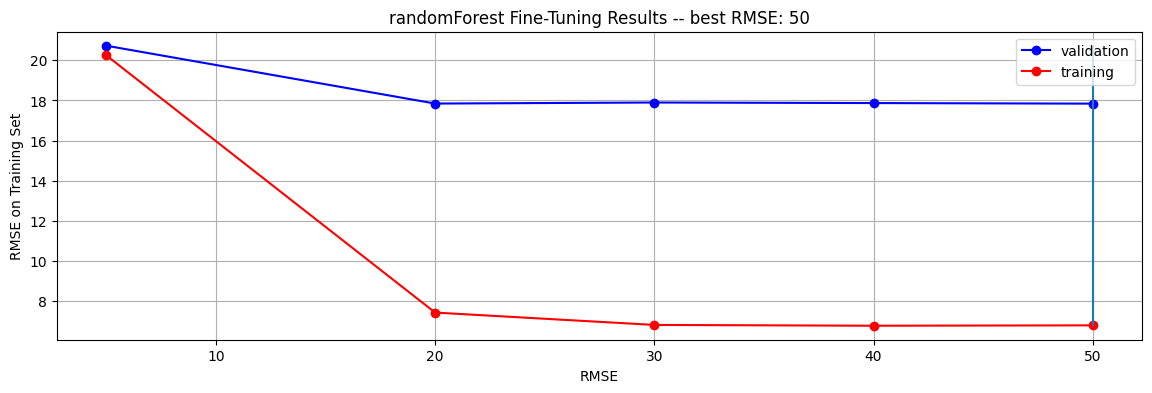

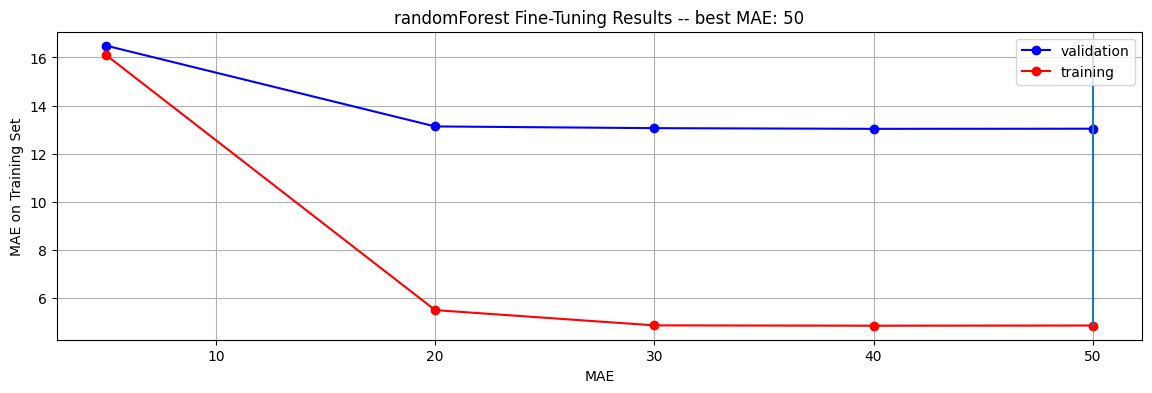

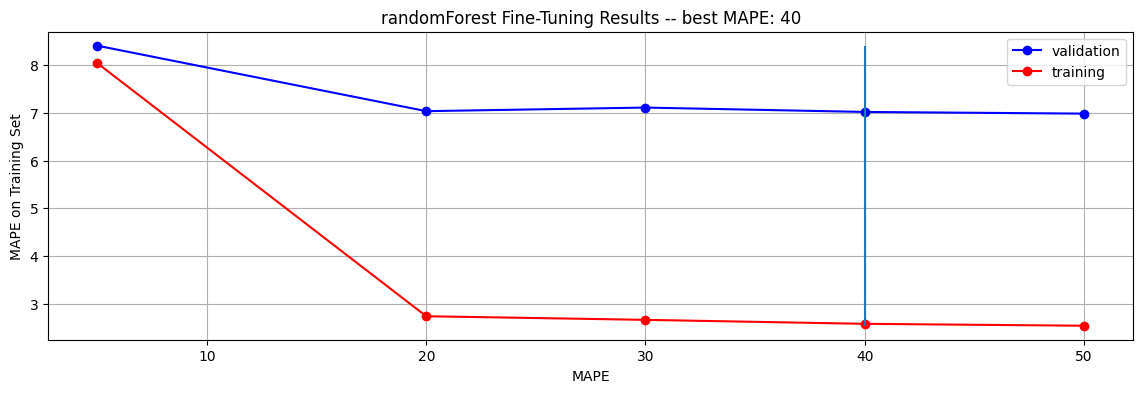

N_ESTIMATORS


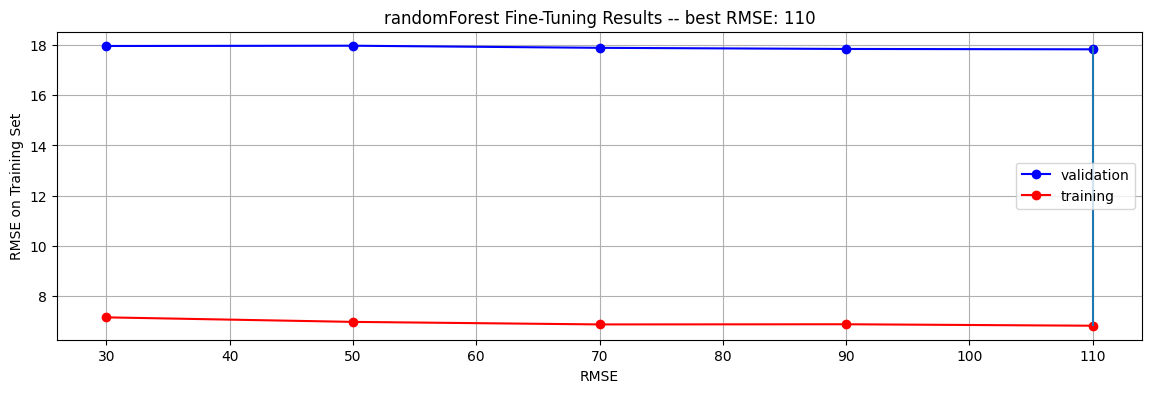

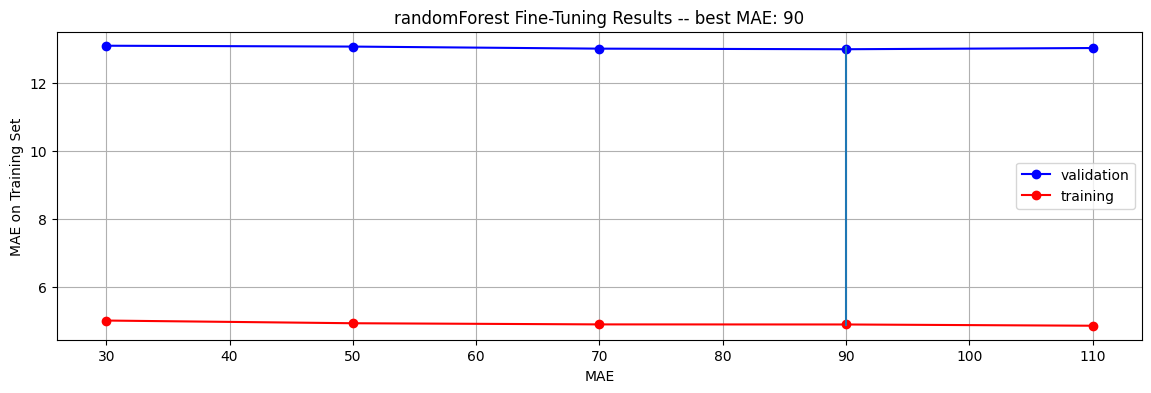

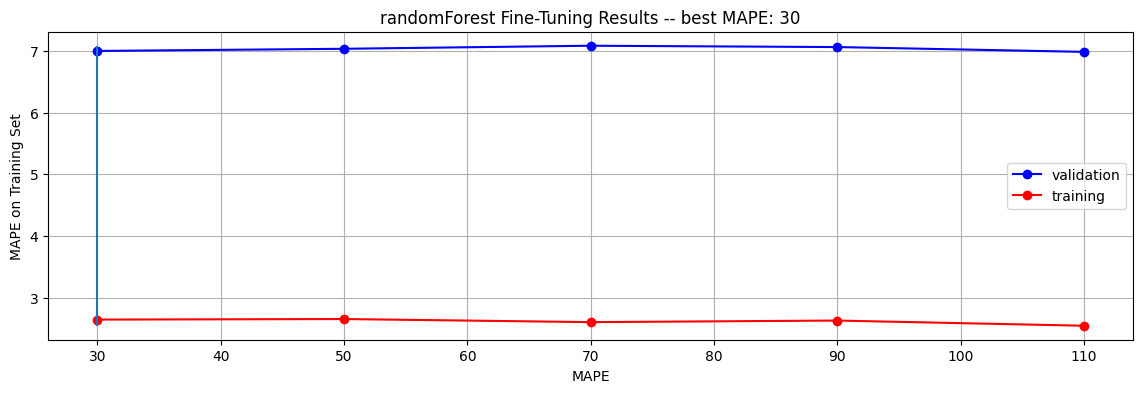

In [56]:

print('='*65)

print('MAX_DEPTH')

print('='*65)

randomForestRegressor.drawFineTunningResults(metricEvaluated='rmse')
randomForestRegressor.drawFineTunningResults(metricEvaluated='mae')
randomForestRegressor.drawFineTunningResults(metricEvaluated='mape')

print('='*65)

print('N_ESTIMATORS')

print('='*65)
randomForestRegressor.drawFineTunningResults(metricEvaluated='rmse', parameterEvaluated='n_estimators')
randomForestRegressor.drawFineTunningResults(metricEvaluated='mae', parameterEvaluated='n_estimators')
randomForestRegressor.drawFineTunningResults(metricEvaluated='mape', parameterEvaluated='n_estimators')


/home/p123/.local/lib/python3.10/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


{'mae': {'training': 4.841977427276233, 'test': 12.999298952525486, 'validation': 12.999285860617109}, 'rmse': {'training': 6.79310848214316, 'test': 17.666667864298653, 'validation': 17.83351854408701}, 'r2': {'training': 0.9034621122672725, 'test': 0.3589843338087444, 'validation': 0.3339756024796732}, 'mape': {'training': 2.656613522009402, 'test': 6.63565965280562, 'validation': 7.139568962263789}, 'modelName': 'DecisionTree', 'modelParams': 'default', 'model': 'DecisionTree'}


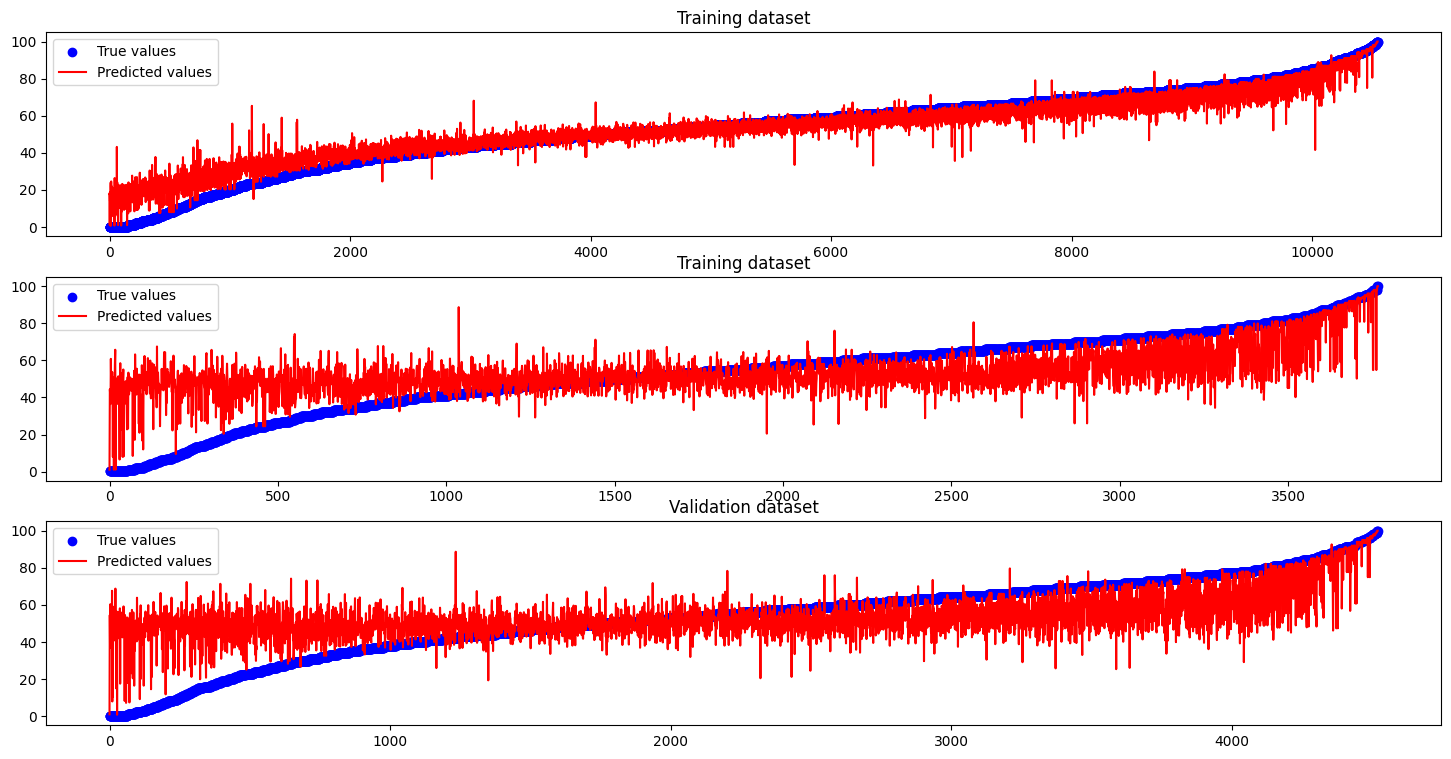

In [ ]:
randomForestRegressor = treeRegressorModels(X_normalized_dataset, y_dataset,
                                            modelName='DecisionTree',
                                            treeRegressor='randomForest')
 
modelKwargs = {
    'max_depth' : ,
    'max_features' : 'log2',
    'n_estimators' : 100
}

randomForestRegressor.fitAndEvaluate(modelKwargs=modelKwargs)

print(randomForestRegressor.model_results)


### 2.2.3 - Regressao polinomial

#### Transformação de variaveis

In [53]:
## feature transform 
degree = 3
pfTransform     = pf(degree = degree, include_bias=False)

# treina a trasformacao com os dados de treino
pfTransform.fit(X_normalized_dataset['training'])

X_poly_dataset  = {}

X_poly_dataset['training']  = pfTransform.transform(X_normalized_dataset['training'])
X_poly_dataset['test']      = pfTransform.transform(X_normalized_dataset['test'])
X_poly_dataset['validation']= pfTransform.transform(X_normalized_dataset['validation'])

print(f'Numero de features originais: {X_normalized_dataset["training"].shape[1]}')
print(f'Numero de features polinomiais (grau={degree}): {X_poly_dataset["training"].shape[1]}')


Numero de features originais: 13
Numero de features polinomiais (grau=3): 559


quanto maior o grau da equação, maior a quantidade de novas features a serem treinadas como lr, o que eleva muito o custo computacional de treinamento. 

Também a tendencia a overfitting neste dataset é extremamente elevada. 


### Treinamento do modelo

{'mae': {'training': 15.883591754200454, 'test': 17.17821403134738, 'validation': 17.08720120651357}, 'rmse': {'training': 20.1046996909489, 'test': 24.78604644476211, 'validation': 22.36797384180136}, 'r2': {'training': 0.15441772140818533, 'test': -0.2617516266887798, 'validation': -0.04777819273864403}, 'mape': {'training': 7.800181445564206, 'test': 7.956229338632625, 'validation': 8.678282574127259}, 'modelName': 'Linear Regression', 'modelParams': 'default', 'model': 'Linear Regression'}


LinearRegression()

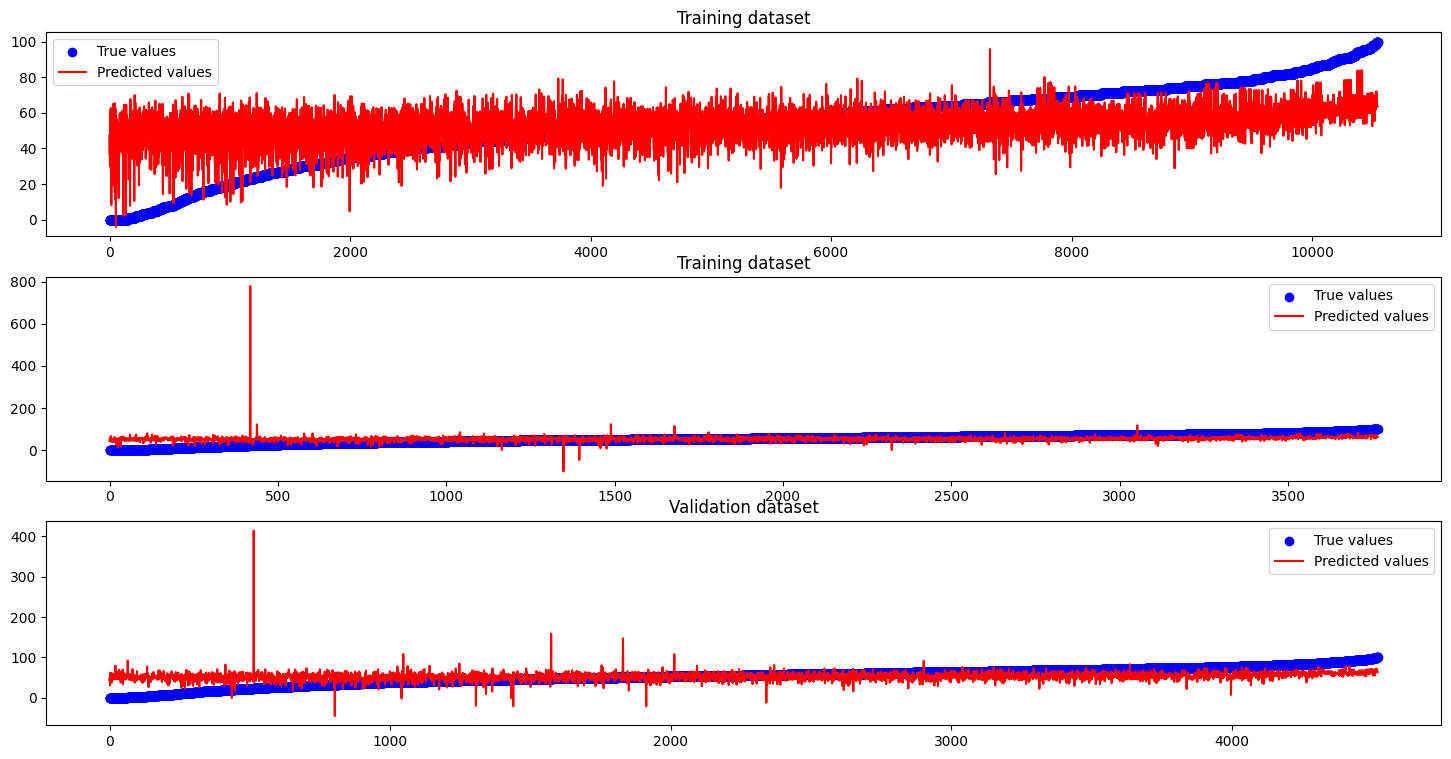

In [54]:
polynomialRegressor = linearRegressionModel(X_poly_dataset, y_dataset) 
polynomialRegressor.fitAndEvaluate(lr())
  

A regressão polinomial tende a "explodir" algumas previsões a depender do grau. Quanto maior o grau da regressão, maior a tendencia a explosão


### Polinomial regularizada

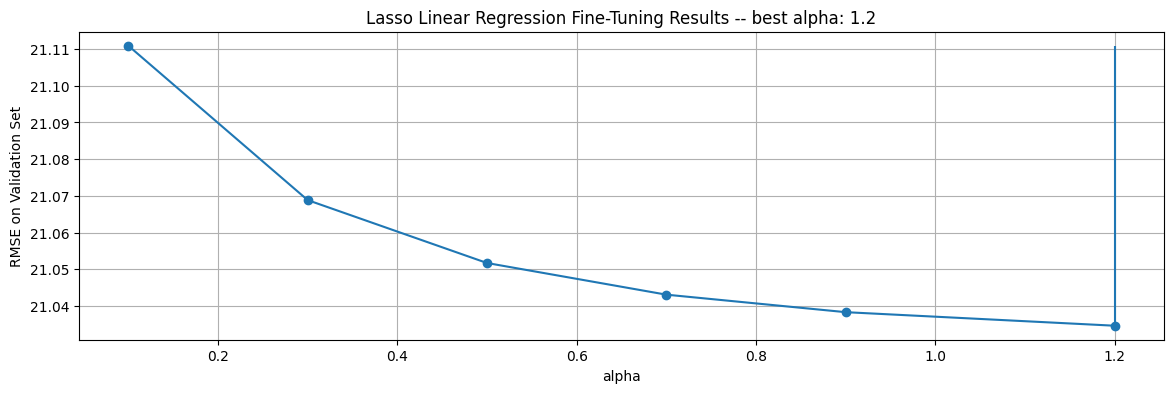

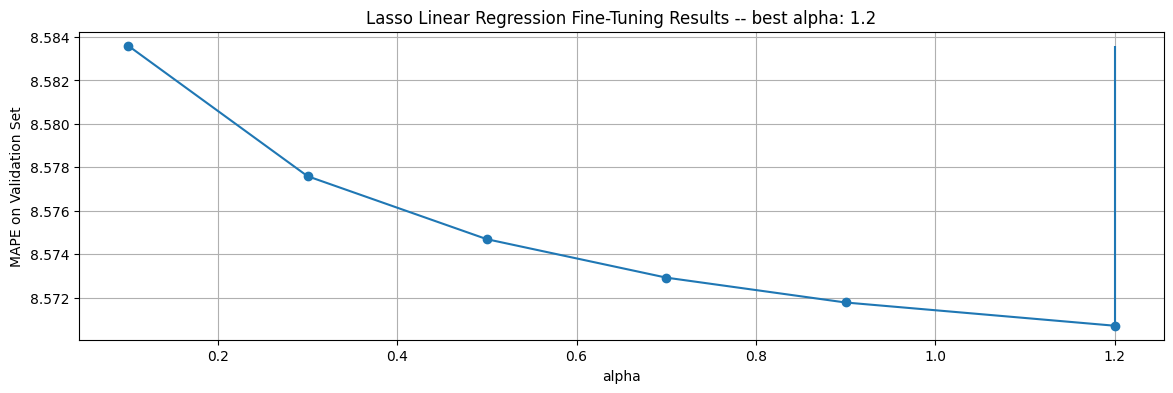

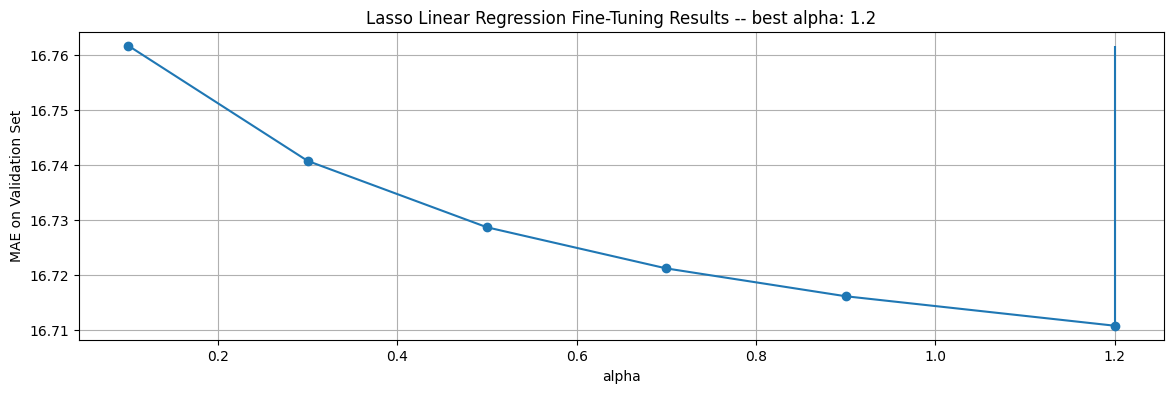

In [65]:
ridgePolynomialRegressor = linearRegressionRegularized(x_dataset=X_poly_dataset, 
                                                 y_dataset=y_dataset,
                                                 modelParams={'alpha':[0.1,0.3,0.5,.7,.9, 1.2]},
                                                 regularization='ridge')
 
ridgePolynomialRegressor.fineTunning()

ridgePolynomialRegressor.drawFineTunningResults(metricEvaluated='rmse')
ridgePolynomialRegressor.drawFineTunningResults(metricEvaluated='mape')
ridgePolynomialRegressor.drawFineTunningResults(metricEvaluated='mae')


Lasso(alpha=0.01)

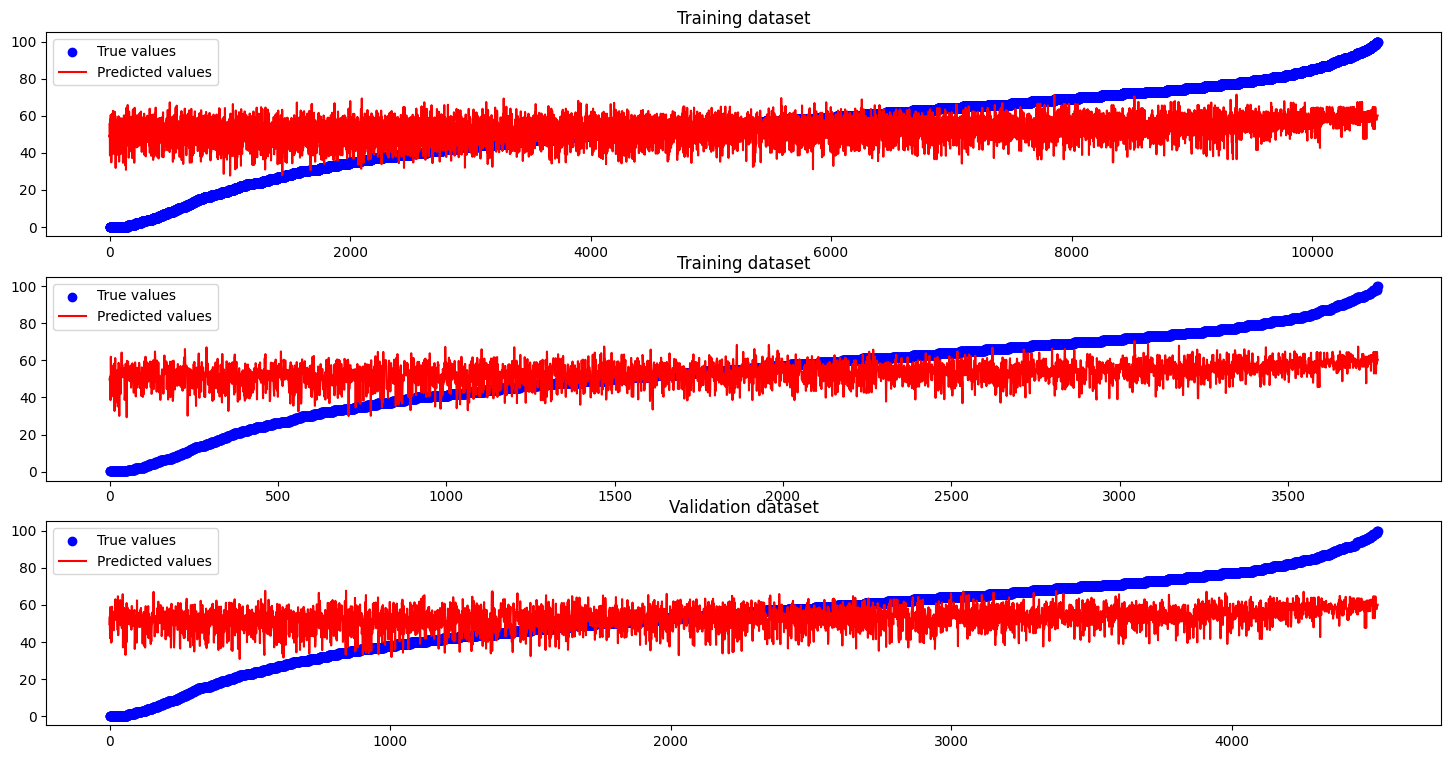

In [66]:
ridgePolynomialRegressor.fitAndEvaluate(ls(alpha = 0.01))


In [67]:
print(ridgePolynomialRegressor.model_results)

{'mae': {'training': 16.510343728969225, 'test': 16.718026842954096, 'validation': 16.692895570779136}, 'rmse': {'training': 20.877539624271183, 'test': 21.03130230637446, 'validation': 21.058660448984398}, 'r2': {'training': 0.08815856055870985, 'test': 0.09156954163782116, 'validation': 0.07129550611638691}, 'mape': {'training': 8.448008172548446, 'test': 8.24264945175969, 'validation': 8.586433999470529}, 'modelName': 'Lasso Linear Regression', 'modelParams': "{'alpha': [0.1, 0.3, 0.5, 0.7, 0.9, 1.2]}", 'model': 'Lasso Linear Regression'}


**Importante:**

A regularização teve um papel extreamemtne importante no treinamento das regressoes polinomiais. 

Quando pensamos em uma equação polinomial, de grau n, cada parametro tem o potencial de possuir uma significancia muito elevada, elevando muito o risco de overfitting. 

Ao regularizar a regressao, nossos parametros se tornam muito menores (efeito smooth, principalmente com a ridge), o modelo tende a simplicidade e se torna menos superajustado/sensível aos parametros. 